# Proyecto Final de Optimización Convexa
## Optimización de hiperparámetros en modelos predictivos

**Acoyani Garrido Sandoval**

---

## 1. Introducción

El objetivo del presente proyecto es aplicar los conceptos aprendidos en el curso de **Optimización Convexa** para resolver un problema de optimización de hiperparámetros en un modelo predictivo.

Los pasos generales del proyecto son:

1. Seleccionar un problema de aprendizaje supervisado o no supervisado.
2. Elegir modelos base con hiperparámetros susceptibles de ser optimizados.
3. Identificar los hiperparámetros críticos y definir un espacio de búsqueda adecuado.
4. Plantear la búsqueda de hiperparámetros como un **problema de optimización convexa** (regularización L1, L2 o *elasticnet*, gradiente descendente, dualidad, condiciones KKT).
5. Implementar la solución en esta notebook.

---

## 2. Selección del conjunto de datos

El conjunto de datos utilizado es el **Telco Customer Churn** (IBM / Kaggle). Fue desarrollado originalmente por IBM como muestra incluida con **IBM Cognos Analytics Server**, una plataforma de inteligencia de negocios.

Este dataset es relevante por dos razones personales:
- Está relacionado con comportamiento de clientes, ámbito en el que opero el negocio **BuzónQR®**.
- Mi primer trabajo (IBM, 2012–2018) consistió en administrar instancias de la plataforma Cognos.

### 2.1 Descripción de las características

Cada fila representa un cliente; las columnas se agrupan en cuatro categorías:

| Grupo | Características |
|---|---|
| **Demográficas** | `gender`, `SeniorCitizen`, `Partner`, `Dependents` |
| **Cuenta** | `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod` |
| **Servicios suscritos** | `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` |
| **Cargos** | `MonthlyCharges`, `TotalCharges` |

**Variable dependiente:** `Churn` (binaria: *Yes* / *No*).  
Distribución de clases: **73.5 % retenidos** / **26.5 % no retenidos** → dataset moderadamente desbalanceado.

### 2.2 *One-hot encoding* y dimensionalidad

Las 15 variables categóricas se convierten a variables indicadoras binarias con `pd.get_dummies(..., drop_first=True)` para evitar la *dummy variable trap* (multicolinealidad perfecta). Las 4 variables ya numéricas (`SeniorCitizen`, `tenure`, `MonthlyCharges`, `TotalCharges`) se mantienen sin transformación, resultando en **30 dimensiones** en total.

Las variables numéricas continuas se estandarizan (media 0, varianza 1) antes del ajuste del modelo, para que la penalización de regularización afecte todos los coeficientes de forma equitativa.

---

## 3. Planteamiento del problema de optimización

### 3.1 Objetivo predictivo

Dado un vector de características $\mathbf{x} \in \mathbb{R}^{30}$ que describe a un cliente, queremos estimar:

$$\Pr(\text{Churn} = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$$

donde $\sigma(\cdot)$ es la función sigmoide, $\mathbf{w} \in \mathbb{R}^{30}$ es el vector de pesos y $b \in \mathbb{R}$ es el sesgo.

### 3.2 Función de pérdida (log-verosimilitud negativa)

Para un conjunto de entrenamiento $\{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ con $y_i \in \{0,1\}$, la pérdida logística es:

$$\mathcal{L}(\mathbf{w}, b) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log \hat{p}_i + (1-y_i) \log(1-\hat{p}_i) \right]$$

donde $\hat{p}_i = \sigma(\mathbf{w}^\top \mathbf{x}_i + b)$.

Esta función es **convexa en $(\mathbf{w}, b)$**, lo que garantiza la existencia de un mínimo global único.

### 3.3 Problema de optimización con regularización

Para controlar la varianza del modelo y forzar escasez o suavidad en los coeficientes, añadimos regularización. El problema de optimización regularizado toma la forma:

$$\min_{\mathbf{w},\, b} \quad \mathcal{L}(\mathbf{w}, b) + \lambda \, \Omega(\mathbf{w})$$

donde la penalización $\Omega(\mathbf{w})$ puede ser:

| Regularización | $\Omega(\mathbf{w})$ | Propiedad |
|---|---|---|
| **L2** (Ridge) | $\frac{1}{2}\|\mathbf{w}\|_2^2$ | Coeficientes pequeños, solución única |
| **L1** (Lasso) | $\|\mathbf{w}\|_1$ | Selección de características (*sparse*) |
| **ElasticNet** | $\alpha\|\mathbf{w}\|_1 + \frac{1-\alpha}{2}\|\mathbf{w}\|_2^2$ | Combinación de ambas |

Dado el desbalance de clases (73.5 % / 26.5 %), se añade también un peso de clase `class_weight='balanced'`, que pondera cada ejemplo $i$ con $w_i \propto 1/\Pr(y_i)$.

El hiperparámetro principal a optimizar es $C = 1/\lambda$ (inverso de la intensidad de regularización), junto con el tipo de penalización.

---

## 4. Implementación

### 4.1 Importación de librerías y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# Ruta al dataset (relativa a esta notebook)
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(DATA_PATH)
print(f"Dimensiones originales: {df.shape}")
df.head()

Dimensiones originales: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 4.2 Preprocesamiento

Pasos:
1. Eliminar `customerID` (identificador sin valor predictivo).
2. Convertir `TotalCharges` a numérico (contiene espacios en blanco para clientes nuevos → imputar con 0).
3. Codificar `Churn` como 1/0.
4. Aplicar *one-hot encoding* con `drop_first=True` a las variables categóricas.
5. Separar características ($X$) y variable dependiente ($y$).
6. Dividir en conjuntos de entrenamiento (80 %) y prueba (20 %) con estratificación.
7. Estandarizar las columnas numéricas continuas.

In [2]:
# 1. Eliminar columna de ID
df = df.drop(columns=["customerID"])

# 2. TotalCharges: convertir a numérico; espacios blancos → NaN → 0
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)

# 3. Codificar variable dependiente
df["Churn"] = (df["Churn"] == "Yes").astype(int)

print("Distribución de Churn:")
print(df["Churn"].value_counts(normalize=True).rename({0: "Retenido (0)", 1: "Abandona (1)"}))

# 4. One-hot encoding de variables categóricas (drop_first para evitar multicolinealidad)
df_encoded = pd.get_dummies(df, drop_first=True)

print(f"\nDimensiones tras one-hot encoding: {df_encoded.shape}")
print(f"Columnas: {list(df_encoded.columns)}")

Distribución de Churn:
Churn
Retenido (0)    0.73463
Abandona (1)    0.26537
Name: proportion, dtype: float64

Dimensiones tras one-hot encoding: (7043, 31)
Columnas: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [3]:
# 5. Separar X e y
y = df_encoded["Churn"]
X = df_encoded.drop(columns=["Churn"])

# 6. Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Estandarizar columnas numéricas continuas
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train = X_train.copy()
X_test = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print(f"Tamaño entrenamiento : {X_train.shape}")
print(f"Tamaño prueba        : {X_test.shape}")
print(f"Prevalencia Churn=1  : {y_train.mean():.3f} (train)  |  {y_test.mean():.3f} (test)")

Tamaño entrenamiento : (5634, 30)
Tamaño prueba        : (1409, 30)
Prevalencia Churn=1  : 0.265 (train)  |  0.265 (test)


### 4.3 Modelo inicial de regresión logística

Ajustamos un primer modelo de regresión logística con regularización **L2** y $C = 1$ (valor predeterminado de `sklearn`) como punto de partida, con `class_weight='balanced'` para compensar el desbalance de clases.

El solver `lbfgs` minimiza internamente la función de pérdida convexa:

$$\min_{\mathbf{w},\, b} \quad \frac{1}{n} \sum_{i=1}^{n} \left[ -y_i \log \sigma_i - (1-y_i) \log(1-\sigma_i) \right] + \frac{1}{2C} \|\mathbf{w}\|_2^2$$

mediante el método de quasi-Newton L-BFGS, que aproxima la inversa del Hessiano usando los últimos $m$ pares gradiente/desplazamiento.

In [4]:
# Modelo base: Regresión Logística L2, C=1, balanced
lr_base = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)
lr_base.fit(X_train, y_train)

# Predicciones
y_pred  = lr_base.predict(X_test)
y_proba = lr_base.predict_proba(X_test)[:, 1]

print("=" * 55)
print("REPORTE DE CLASIFICACIÓN — Modelo base (L2, C=1)")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Retenido", "Abandona"]))
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")

REPORTE DE CLASIFICACIÓN — Modelo base (L2, C=1)
              precision    recall  f1-score   support

    Retenido       0.90      0.72      0.80      1035
    Abandona       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

AUC-ROC: 0.8417


c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


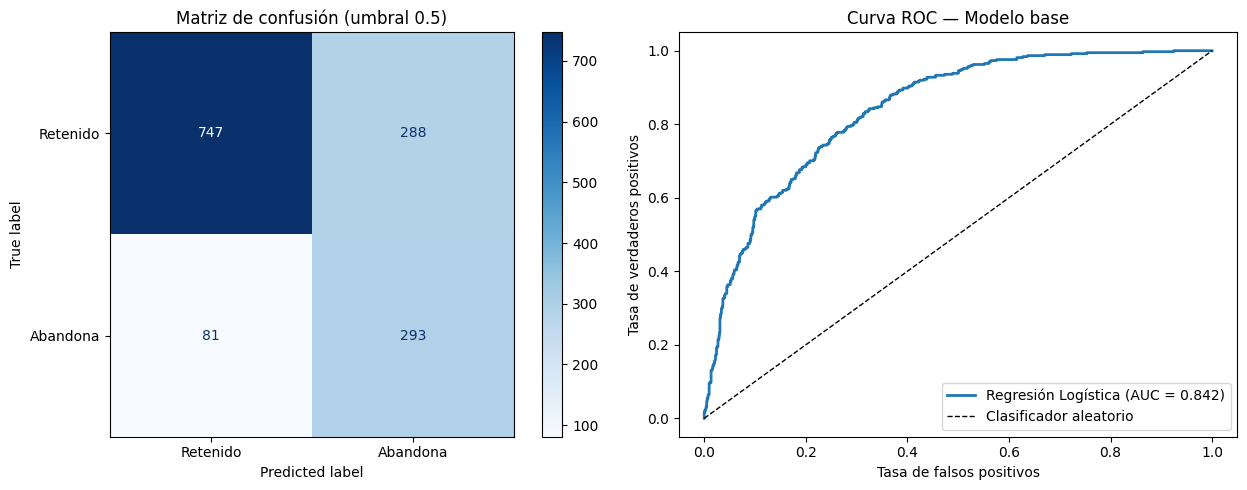

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Matriz de confusión ---
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Retenido", "Abandona"],
    cmap="Blues",
    ax=axes[0]
)
axes[0].set_title("Matriz de confusión (umbral 0.5)")

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, lw=2, label=f"Regresión Logística (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC — Modelo base")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

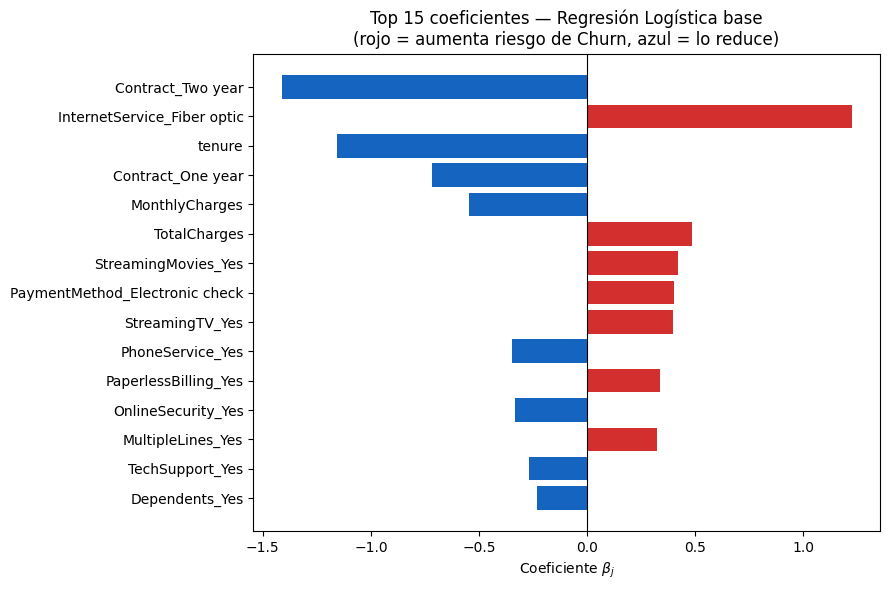

In [6]:
# Coeficientes del modelo (ordenados por magnitud absoluta)
coef_df = pd.DataFrame({
    "Característica": X_train.columns,
    "Coeficiente": lr_base.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(15)

plt.figure(figsize=(9, 6))
colors = ["#d32f2f" if c > 0 else "#1565c0" for c in coef_df["Coeficiente"]]
plt.barh(coef_df["Característica"], coef_df["Coeficiente"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Coeficiente $\\beta_j$")
plt.title("Top 15 coeficientes — Regresión Logística base\n(rojo = aumenta riesgo de Churn, azul = lo reduce)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 4.4 Validación cruzada del modelo base

Para obtener una estimación más robusta del desempeño se realiza una validación cruzada estratificada de 5 pliegues sobre el conjunto de entrenamiento completo.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(lr_base, X_train, y_train, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(lr_base, X_train, y_train, cv=cv, scoring="f1")

print("Validación cruzada 5-fold — Modelo base (L2, C=1)")
print(f"  AUC-ROC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")
print()
print("Estos resultados sirven como línea base para comparar con modelos optimizados.")

c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 

Validación cruzada 5-fold — Modelo base (L2, C=1)
  AUC-ROC : 0.8459 ± 0.0124
  F1      : 0.6296  ± 0.0226

Estos resultados sirven como línea base para comparar con modelos optimizados.


c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Midriffy\Code\ITESO\semestre2\optimizacion\PROFINAL\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 